In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

In [2]:
df15 = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\detik2015.csv")
df16 = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\detik2016.csv")
df17 = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\detik2017.csv")
df18 = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\detik2018.csv")
df1925 = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\scraping_cnbc_BBCA_sorted_2019_2025.csv")

In [3]:
df15.head()

,title,released,url,content
0,RUPS dan RUPSLB: PT Bank Central Asia Tbk (BBC...,2015-04-09,https://finance.detik.com/kalender-bursa/d-288...,RUPS dan RUPSLB: PT Bank Central Asia Tbk (BBC...
1,Bahana Securities: IHSG Diperkirakan Melemah,2015-12-01,https://finance.detik.com/market-research/d-30...,MENUdetikcomTerpopulerLive TVKirim TulisanKate...
2,Pelaku Pasar Saham Menanti Keputusan The Fed,2015-09-15,https://finance.detik.com/market-research/d-30...,MENUdetikcomTerpopulerLive TVKirim TulisanKate...
3,Bahana Securities: IHSG dan Rupiah Masih Berpo...,2015-08-25,https://finance.detik.com/market-research/d-30...,MENUdetikcomTerpopulerLive TVKirim TulisanKate...
4,"Sempat Jatuh, IHSG Siang Ini Stagnan",2015-12-21,https://finance.detik.com/bursa-dan-valas/d-31...,MENUdetikcomTerpopulerLive TVKirim TulisanKate...


In [4]:
df1925.head()

,Publish_date,URL,Title,Keyword,Date
0,2019-01-01 12:25:44,https://www.cnbcindonesia.com/market/201901011...,Ini 5 Saham yang Paling Banyak Diborong Asing ...,BBCA,2019/01/01
1,2019-01-01 12:25:44,https://www.cnbcindonesia.com/market/201901011...,Ini 5 Saham yang Paling Banyak Diborong Asing ...,Bank Central Asia,2019/01/01
2,2019-01-02 08:30:37,https://www.cnbcindonesia.com/market/201901020...,"Simak! JSMR Dapat Utang, Saham Grup Bakrie",Bank Central Asia,2019/01/02
3,2019-01-02 12:39:45,https://www.cnbcindonesia.com/market/201901021...,Asing Borong Saham Big Cap saat IHSG di Zona M...,BBCA,2019/01/02
4,2019-01-02 12:39:45,https://www.cnbcindonesia.com/market/201901021...,Asing Borong Saham Big Cap saat IHSG di Zona M...,Bank Central Asia,2019/01/02


In [5]:
df15['released'] = pd.to_datetime(df15['released'])
df16['released'] = pd.to_datetime(df16['released'])
df17['released'] = pd.to_datetime(df17['released'])
df18['released'] = pd.to_datetime(df18['released'])
df1925['Date'] = pd.to_datetime(df1925['Date'])

In [6]:
df15 = df15.rename(columns={
    'title': 'Title',
    'released': 'Date' 
})

df15 = df15.drop(['url', 'content'], axis=1)

In [7]:
df16 = df16.rename(columns={
    'title': 'Title',
    'released': 'Date' 
})

df16 = df16.drop(['url', 'content'], axis=1)

In [8]:
df17 = df17.rename(columns={
    'title': 'Title',
    'released': 'Date' 
})

df17 = df17.drop(['url', 'content'], axis=1)

In [9]:
df18 = df18.rename(columns={
    'title': 'Title',
    'released': 'Date' 
})

df18 = df18.drop(['url', 'content'], axis=1)

In [10]:
df1925 = df1925.drop(['Publish_date', 'URL', 'Keyword'], axis=1)

In [67]:
df_final = pd.concat([df15, df16, df17, df18, df1925], ignore_index=True)
print(f"Hasil concatenate: {df_final.shape}")
print(df_final.head())

Hasil concatenate: (11059, 2)
                                               Title       Date
0  RUPS dan RUPSLB: PT Bank Central Asia Tbk (BBC... 2015-04-09
1       Bahana Securities: IHSG Diperkirakan Melemah 2015-12-01
2       Pelaku Pasar Saham Menanti Keputusan The Fed 2015-09-15
3  Bahana Securities: IHSG dan Rupiah Masih Berpo... 2015-08-25
4               Sempat Jatuh, IHSG Siang Ini Stagnan 2015-12-21


In [69]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11059 entries, 0 to 11058
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Title   11035 non-null  object        
 1   Date    11059 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 172.9+ KB



Rentang Tanggal: 2015-01-01 00:00:00 sampai 2025-10-03 00:00:00
Total hari dengan data: 2860


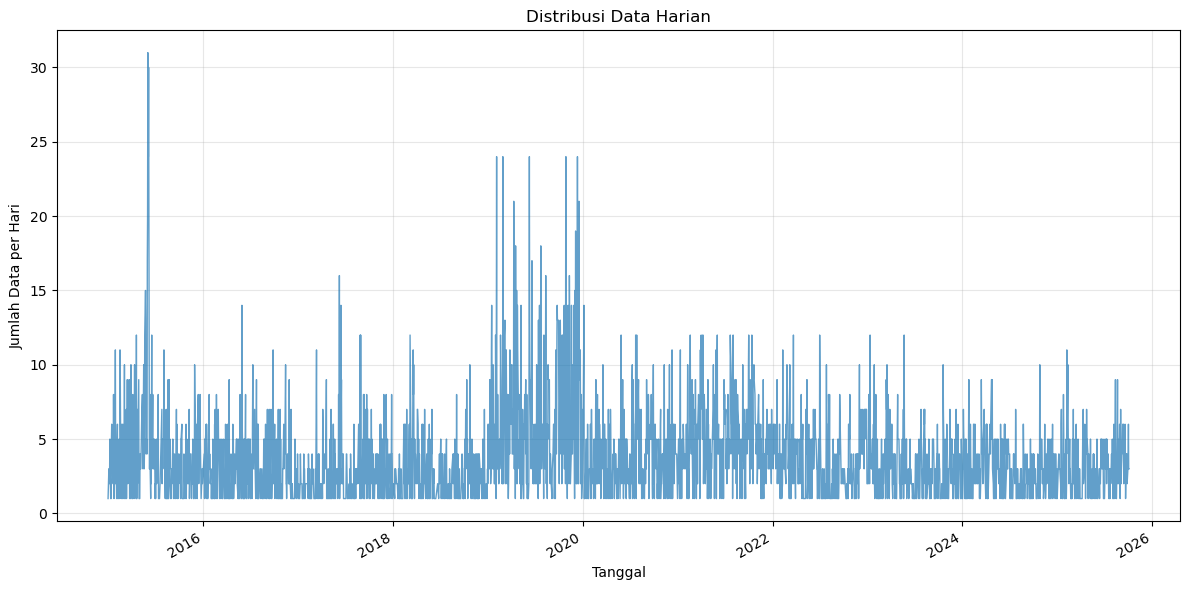

In [71]:
# Time series harian
daily_count = df_final.groupby('Date').size()
print(f"\nRentang Tanggal: {df_final['Date'].min()} sampai {df_final['Date'].max()}")
print(f"Total hari dengan data: {len(daily_count)}")

plt.figure(figsize=(12, 6))
daily_count.plot(alpha=0.7, linewidth=1)
plt.title('Distribusi Data Harian')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Data per Hari')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


DISTRIBUSI PER HARI DALAM MINGGU:
DayOfWeek
Monday       2466
Tuesday      2001
Wednesday    1909
Thursday     2199
Friday       1905
Saturday      317
Sunday        262
Name: count, dtype: int64


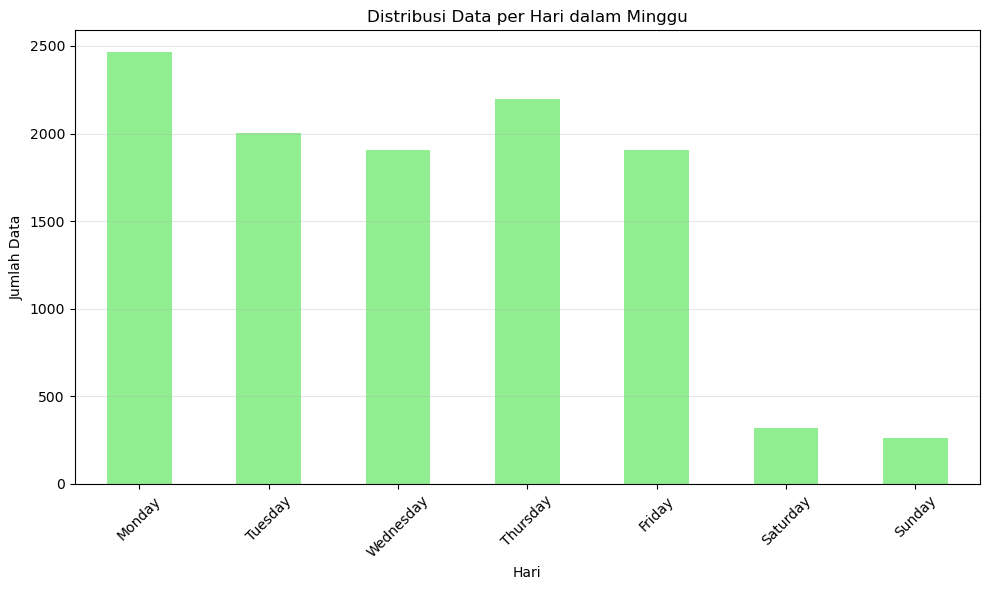

In [73]:
# Distribusi per hari dalam minggu
df_final['DayOfWeek'] = df_final['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_dist = df_final['DayOfWeek'].value_counts().reindex(day_order)

print("\nDISTRIBUSI PER HARI DALAM MINGGU:")
print(day_dist)

plt.figure(figsize=(10, 6))
day_dist.plot(kind='bar', color='lightgreen')
plt.title('Distribusi Data per Hari dalam Minggu')
plt.xlabel('Hari')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
import pandas as pd

# Buat rentang tanggal lengkap dari min sampai max
full_date_range = pd.date_range(
    start=df_final['Date'].min(), 
    end=df_final['Date'].max(), 
    freq='D'
)

# Tanggal yang ada di data
existing_dates = set(df_final['Date'])

# Tanggal yang tidak ada (missing dates)
missing_dates = sorted(set(full_date_range) - existing_dates)

print(f"Rentang tanggal: {df_final['Date'].min()} sampai {df_final['Date'].max()}")
print(f"Total hari dalam rentang: {len(full_date_range)}")
print(f"Hari dengan data: {len(existing_dates)}")
print(f"Hari TANPA data: {len(missing_dates)}")
print(f"Persentase hari dengan data: {len(existing_dates)/len(full_date_range)*100:.1f}%")

Rentang tanggal: 2015-01-01 00:00:00 sampai 2025-10-03 00:00:00
Total hari dalam rentang: 3929
Hari dengan data: 2860
Hari TANPA data: 1069
Persentase hari dengan data: 72.8%


In [81]:
print("\nDETAIL TANGGAL YANG HILANG:")
print("=" * 50)

# Tampilkan SEMUA tanggal yang hilang
print(f"\nSEMUA TANGGAL TANPA DATA ({len(missing_dates)} hari):")
print("-" * 40)

for i, date in enumerate(missing_dates, 1):
    print(f"{i:3d}. {date.strftime('%Y-%m-%d')} ({date.strftime('%A')})")

print(f"\nTotal: {len(missing_dates)} hari tanpa data")


DETAIL TANGGAL YANG HILANG:

SEMUA TANGGAL TANPA DATA (1069 hari):
----------------------------------------
  1. 2015-01-02 (Friday)
  2. 2015-01-03 (Saturday)
  3. 2015-01-05 (Monday)
  4. 2015-01-10 (Saturday)
  5. 2015-01-16 (Friday)
  6. 2015-01-17 (Saturday)
  7. 2015-01-18 (Sunday)
  8. 2015-01-25 (Sunday)
  9. 2015-01-28 (Wednesday)
 10. 2015-02-01 (Sunday)
 11. 2015-02-08 (Sunday)
 12. 2015-02-14 (Saturday)
 13. 2015-02-19 (Thursday)
 14. 2015-02-22 (Sunday)
 15. 2015-02-24 (Tuesday)
 16. 2015-03-01 (Sunday)
 17. 2015-03-14 (Saturday)
 18. 2015-03-15 (Sunday)
 19. 2015-03-21 (Saturday)
 20. 2015-03-29 (Sunday)
 21. 2015-03-31 (Tuesday)
 22. 2015-04-02 (Thursday)
 23. 2015-04-04 (Saturday)
 24. 2015-04-12 (Sunday)
 25. 2015-04-25 (Saturday)
 26. 2015-04-26 (Sunday)
 27. 2015-05-02 (Saturday)
 28. 2015-05-06 (Wednesday)
 29. 2015-05-09 (Saturday)
 30. 2015-05-10 (Sunday)
 31. 2015-05-12 (Tuesday)
 32. 2015-05-14 (Thursday)
 33. 2015-05-16 (Saturday)
 34. 2015-05-17 (Sunday)
 35.

In [85]:
# urutkan dari tanggal paling kecil (terlama)
df_final = df_final.sort_values(by='Date', ascending=True)

# simpan ulang ke CSV
df_final.to_csv("scraping_cnbc_BBCA_sorted.csv", index=False, encoding='utf-8-sig')

print("✅ Data berhasil diurutkan dan disimpan ke scraping_cnbc_BBCA_sorted.csv")


✅ Data berhasil diurutkan dan disimpan ke scraping_cnbc_BBCA_sorted.csv


## Merger Data Sentimen - ARIMA - LSTM

In [22]:
df_harga = pd.read_excel(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\Data_BBCA_2015_sampai_sekarang.xlsx")
df_sentimen = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\daily_sentiment.csv")
df_arima = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\residual_ARIMA_2015_2025.csv")

df_harga = df_harga.drop(df_harga.index[0:2])
df_harga.head(10)

,Price,Close,High,Low,Open,Volume
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07 00:00:00,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08 00:00:00,2130.166504,2158.897073,2130.166504,2154.792706,54457000
7,2015-01-09 00:00:00,2121.956787,2146.582978,2121.956787,2138.374248,108957500
8,2015-01-12 00:00:00,2134.270508,2134.270508,2101.435577,2121.957409,81651000
9,2015-01-13 00:00:00,2134.270508,2142.479241,2130.166141,2142.479241,36024000
10,2015-01-14 00:00:00,2121.956787,2138.374248,2121.956787,2138.374248,29728000
11,2015-01-15 00:00:00,2126.061279,2142.478741,2126.061279,2126.061279,27580500


In [24]:
df_harga['Price'] = pd.to_datetime(df_harga['Price'])

df_harga = df_harga.rename(columns={'Price': 'Date'})

df_harga = df_harga.sort_values("Date")
df_sentimen["Date"] = pd.to_datetime(df_sentimen["Date"])
df_arima["Date"] = pd.to_datetime(df_arima["Date"])

In [26]:
merge1 = pd.merge(df_harga, df_sentimen, on="Date", how="left")
final_df = pd.merge(merge1, df_arima, on="Date", how="left")

In [30]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2653 non-null   datetime64[ns]
 1   Close_x         2653 non-null   object        
 2   High            2653 non-null   object        
 3   Low             2653 non-null   object        
 4   Open            2653 non-null   object        
 5   Volume          2653 non-null   object        
 6   SentimentScore  2651 non-null   float64       
 7   NumComments     2651 non-null   float64       
 8   HasComment      2651 non-null   float64       
 9   Close_y         2653 non-null   float64       
 10  Residual        2653 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 228.1+ KB


In [38]:
final_df.tail(15)

,Date,Close_x,High,Low,Open,Volume,SentimentScore,NumComments,HasComment,Close_y,Residual
2638,2025-09-17,7850,7900,7800,7850,183725900,0.000000,5.0,1.0,7850.0,-79.422999
2639,2025-09-18,7700,7900,7650,7850,275378700,-0.333333,6.0,1.0,7700.0,-167.131289
2640,2025-09-19,7800,7825,7650,7650,149025300,0.000000,3.0,1.0,7800.0,72.400578
2641,2025-09-22,7725,7825,7725,7800,92588800,-0.333333,3.0,1.0,7725.0,-79.393297
2642,2025-09-23,7875,7900,7750,7750,102606200,0.000000,4.0,1.0,7875.0,143.141367
2643,2025-09-24,7775,7950,7725,7950,150428400,0.000000,3.0,1.0,7775.0,-89.977826
2644,2025-09-25,7700,7775,7700,7725,147986600,0.000000,4.0,1.0,7700.0,-78.434658
2645,2025-09-26,7625,7700,7575,7575,121657700,0.500000,2.0,1.0,7625.0,-92.547576
2646,2025-09-29,7775,7800,7700,7750,116454700,-0.333333,3.0,1.0,7775.0,131.509395
2647,2025-09-30,7625,7775,7625,7700,170666700,0.000000,4.0,1.0,7625.0,-142.263495


In [44]:
# Isi missing value jika ada
final_df.fillna(0, inplace=True)

# Simpan hasil merge
final_df.to_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\merged_BBCA_sentiment_arima.csv", index=False)

final_df.tail(15)

,Date,Close_x,High,Low,Open,Volume,SentimentScore,NumComments,HasComment,Close_y,Residual
2638,2025-09-17,7850,7900,7800,7850,183725900,0.000000,5.0,1.0,7850.0,-79.422999
2639,2025-09-18,7700,7900,7650,7850,275378700,-0.333333,6.0,1.0,7700.0,-167.131289
2640,2025-09-19,7800,7825,7650,7650,149025300,0.000000,3.0,1.0,7800.0,72.400578
2641,2025-09-22,7725,7825,7725,7800,92588800,-0.333333,3.0,1.0,7725.0,-79.393297
2642,2025-09-23,7875,7900,7750,7750,102606200,0.000000,4.0,1.0,7875.0,143.141367
2643,2025-09-24,7775,7950,7725,7950,150428400,0.000000,3.0,1.0,7775.0,-89.977826
2644,2025-09-25,7700,7775,7700,7725,147986600,0.000000,4.0,1.0,7700.0,-78.434658
2645,2025-09-26,7625,7700,7575,7575,121657700,0.500000,2.0,1.0,7625.0,-92.547576
2646,2025-09-29,7775,7800,7700,7750,116454700,-0.333333,3.0,1.0,7775.0,131.509395
2647,2025-09-30,7625,7775,7625,7700,170666700,0.000000,4.0,1.0,7625.0,-142.263495
